# Efficacité coût / usage

L'étape 3 disait qui coûte cher. Ici on regarde ce qu'on obtient pour cet argent :
d'où vient exactement le coût, et est-ce que les ressources les plus chères sont bien
celles qu'on utilise le plus.

## 1. Chargement

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/gcp_costs_clean.csv", parse_dates=["usage_start", "usage_end"])
df.head()

,resource_id,service,usage_quantity,usage_unit,region,cpu_util_pct,memory_util_pct,net_in_bytes,net_out_bytes,usage_start,usage_end,cost_per_quantity,cost_usd,duree_jours
0,res-ST6BAJ2N,Cloud Dataproc,954.9843,Requests,europe-north1,92.72,70.42,77097035547,8.268593e+10,2024-08-01 22:24:00,2024-08-07 06:54:00,5.24,5004.12,5.354167
1,res-TYGNR0RV,Pub/Sub,479.6348,GB,europe-west1,37.78,46.80,8239357017,1.135149e+10,2024-08-23 09:18:00,2024-08-25 07:26:00,9.82,4710.01,1.922222
2,res-S3I9C869,BigQuery,114.4129,GB,southamerica-east1,82.54,59.47,23358691883,2.345081e+10,2024-07-18 11:13:00,2024-07-22 00:45:00,7.37,843.22,3.563889
3,res-1RY9BZ6G,Cloud Endpoints,413.1930,GB,us-central1,86.68,97.63,53404385778,6.078019e+10,2024-07-20 00:15:00,2024-07-21 10:16:00,4.41,1822.18,1.417361
4,res-S3HQYIZ2,Cloud Spanner,335.9892,GB,asia-southeast1,82.95,21.58,10795270461,1.416138e+10,2024-08-21 21:25:00,2024-08-25 00:21:00,6.09,2046.17,3.122222


## 2. Composition du coût

Trois colonnes parlent d'argent : `usage_quantity`,
`cost_per_quantity` et `cost_usd`. On vérifie si la
facture est simplement la multiplication des deux.

In [2]:
calcul = df["usage_quantity"] * df["cost_per_quantity"]

ecart = (calcul - df["cost_usd"]).abs()  # .abs() : on veut l'écart, peu importe le signe
print(f"écart max avec cost_usd : {ecart.max():.4f} USD")

écart max avec cost_usd : 0.0050 USD


C'est l'arrondi de `cost_usd` à deux décimales. La formule est donc exacte, la facture c'est **quantité × prix unitaire**.

## 3. Récapitulatif par service

In [3]:
recap = df.groupby("service").agg(
    nb_ressources=("resource_id", "count"),
    cout_total=("cost_usd", "sum"),
    cout_moyen=("cost_usd", "mean"),
    quantite_moyenne=("usage_quantity", "mean"),
    prix_unitaire=("cost_per_quantity", "mean"),
    cpu_moyen=("cpu_util_pct", "mean"),
).sort_values("cout_moyen", ascending=False).round(2)

recap

,nb_ressources,cout_total,cout_moyen,quantite_moyenne,prix_unitaire,cpu_moyen
service,,,,,,
Cloud NAT,35,118601.48,3388.61,564.61,6.00,53.27
Cloud Data Fusion,25,83777.36,3351.09,523.17,6.53,55.68
Cloud Load Balancing,32,98834.05,3088.56,528.93,6.12,48.42
Cloud SQL,35,101202.05,2891.49,514.96,5.36,51.69
Container Registry,30,85370.73,2845.69,500.38,5.91,56.67
Cloud Build,48,135186.56,2816.39,474.18,5.68,50.52
Cloud CDN,51,141420.87,2772.96,500.03,5.64,50.79
Cloud Endpoints,41,113136.97,2759.44,448.95,5.81,55.40
Cloud Dataproc,38,104540.83,2751.07,503.15,5.08,47.54


<Axes: title={'center': "Coût moyen d'une ressource, par service (USD)"}, ylabel='service'>

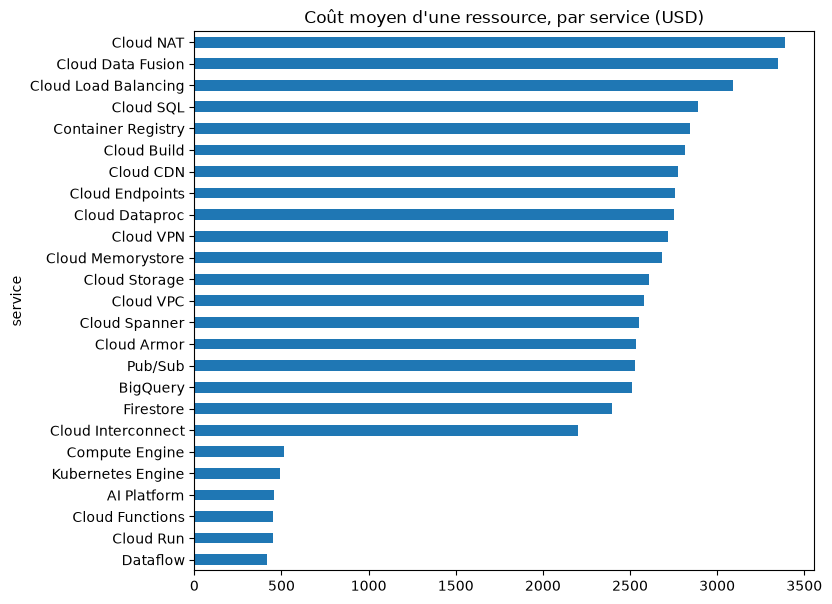

In [4]:
recap["cout_moyen"].sort_values().plot(
    kind="barh", figsize=(8, 7), title="Coût moyen d'une ressource, par service (USD)"
)

Six services se détachent, on voit environ 450 par ressource contre 2 500 $ pour
les autres.

## 4. Effet de l'unité de facturation

In [5]:
pd.crosstab(df["service"], df["usage_unit"])

usage_unit,GB,Hours,Requests
service,,,
AI Platform,0,40,0
BigQuery,17,0,22
Cloud Armor,21,0,18
Cloud Build,28,0,20
Cloud CDN,28,0,23
Cloud Data Fusion,13,0,12
Cloud Dataproc,13,0,25
Cloud Endpoints,22,0,19
Cloud Functions,0,38,0


In [6]:
df.groupby("usage_unit").agg(
    nb_ressources=("resource_id", "count"),
    quantite_moyenne=("usage_quantity", "mean"),
    cout_moyen=("cost_usd", "mean"),
).round(1)

,nb_ressources,quantite_moyenne,cout_moyen
usage_unit,,,
GB,370,495.6,2728.7
Hours,256,83.9,465.8
Requests,374,477.2,2690.8


Les six services pas chers sont ceux facturés en **heures**, les autres en **GB** ou en **requêtes**. On ne compare pas des heures aux GB, l'écart vient de l'unité de facturation.

## 5. Coût et utilisation

In [7]:
colonnes = ["cost_usd", "usage_quantity", "cost_per_quantity", "cpu_util_pct", "memory_util_pct", "duree_jours"]

df[colonnes].corr().round(2)

,cost_usd,usage_quantity,cost_per_quantity,cpu_util_pct,memory_util_pct,duree_jours
cost_usd,1.00,0.81,0.48,-0.05,-0.02,0.02
usage_quantity,0.81,1.00,0.03,-0.04,-0.02,0.04
cost_per_quantity,0.48,0.03,1.00,-0.06,-0.03,0.01
cpu_util_pct,-0.05,-0.04,-0.06,1.00,0.01,0.03
memory_util_pct,-0.02,-0.02,-0.03,0.01,1.00,-0.03
duree_jours,0.02,0.04,0.01,0.03,-0.03,1.00


<Axes: title={'center': 'Coût vs utilisation CPU'}, xlabel='cpu_util_pct', ylabel='cost_usd'>

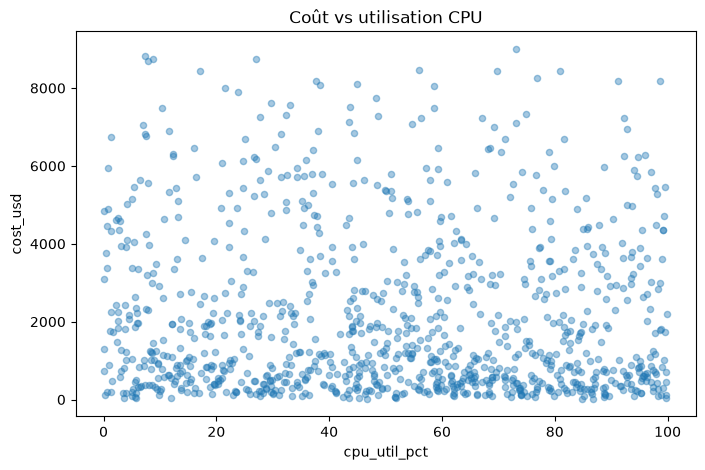

In [8]:
df.plot(
    kind="scatter", x="cpu_util_pct", y="cost_usd", alpha=0.4, figsize=(8, 5),
    title="Coût vs utilisation CPU",
)

La colonne `cost_usd` est liée à `usage_quantity` (0,81) et un peu au prix unitaire
(0,48), mais pas du tout au CPU (-0,05) ni à la mémoire (-0,02). 
Le nuage de points le
confirme, aucune forme, les ressources chères ne sont pas les plus utilisées.

## 6. Ressources peu utilisées

Le CPU va de 0 à 100 %. Avec `pd.cut` ça le découpe en trois tranches nommées, la colonne devient une catégorie, sur laquelle on peut donc faire un `groupby`.

In [9]:
df["niveau_cpu"] = pd.cut(df["cpu_util_pct"], bins=[0, 30, 70, 100], labels=["faible", "moyen", "fort"])

df.groupby("niveau_cpu", observed=True).agg(
    nb_ressources=("resource_id", "count"),
    cout_total=("cost_usd", "sum"),
    cout_moyen=("cost_usd", "mean"),
).round(0)

,nb_ressources,cout_total,cout_moyen
niveau_cpu,,,
faible,284,631776.0,2225.0
moyen,415,894161.0,2155.0
fort,301,609277.0,2024.0


284 ressources tournent sous 30 % de CPU et pèsent 632 000 $, soit environ 30 % de la
facture.. Et le coût moyen est presque le même dans les
trois tranches (~2 100 $), ce qui redit la conclusion de l'étape 5 : ce qu'on paie ne
dit rien de ce qu'on utilise.

## Synthèse

- **Composition du coût** : `cost_usd` = `usage_quantity` × `cost_per_quantity`. Le CPU,
  la mémoire et la durée n'entrent jamais dans le calcul
- **Récapitulatif par service** : 6 services se détachent avec un coût moyen bas
  d'environ 450 par ressource contre ~2 500 $ pour les 19 autres
- **Effet de l'unité de facturation** : cet écart n'a rien à voir avec l'efficacité des
  services, ce sont justement les 6 facturés en heures (~84 unités en moyenne) contre
  GB ou requêtes (~490 unités) pour les autres. Le prix unitaire, lui, est stable partout
  (4,8 à 6,5 $)
- **Coût et utilisation** : aucun lien entre le coût et l'usage réel, confirmé par le nuage de points sans forme. Payer plus ne veut pas dire utiliser plus
- **Ressources peu utilisées** : 284 ressources tournent sous 30 % de CPU et pèsent
  632 000 $, soit 30 % de la facture totale : c'est la marge de manœuvre